<a href="https://colab.research.google.com/github/BibhusanSilwal/EPL-sentiment-analysis/blob/main/epl_twitter_sentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EPL Twitter Sentiment Analysis

This notebook performs sentiment analysis on EPL teams' Twitter data using:
- Logistic Regression with TF-IDF
- BERT (bert-base-uncased)



## 1. Install Dependencies & Imports

Install required packages and import libraries for NLP, ML, and visualization. This sets up VADER (for validation), spaCy (lemmatization), scikit-learn (Logistic Regression), and Hugging Face (BERT).

**Key Imports**:
- `pandas`, `nltk`: Data handling & tokenization.
- `spacy`: Lemmatization.
- `sklearn`: TF-IDF, Logistic Regression.
- `transformers`, `torch`: BERT fine-tuning.
- `matplotlib`, `seaborn`: Plots.

Run once; restart runtime if issues.

In [ ]:

# Install required libraries (run once)
!pip install vaderSentiment nltk scikit-learn transformers torch datasets evaluate spacy emoji
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 27.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:

import os
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem.porter import PorterStemmer
import emoji
import spacy

from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import torch


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
os.makedirs('data/', exist_ok=True)
os.makedirs('./results', exist_ok=True)

## 2. Load Dataset

Load CSV files from `data/` folder (EPL tweets with columns like `text`, `polarity`). Concatenate into a single DataFrame.

**Steps**:
- Scan for `.csv` files.
- Handle errors with `on_bad_lines='skip'`.
- Output: `df` shape ~ (211k, 15).

**Note**: Assumes files are pre-scraped; polarity pre-computed (-1 to +1 scale).

In [ ]:
def load_dataset(folder_path='data/'):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    df_list = []

    for file in all_files:
        try:
            df_temp = pd.read_csv(
                os.path.join(folder_path, file),
                engine='python',
                on_bad_lines='skip'
            )
            df_list.append(df_temp)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    df = pd.concat(df_list, ignore_index=True)
    return df

df = load_dataset()
print(df.shape)


(211342, 15)


In [ ]:
df.columns


Index(['created_at', 'file_name', 'followers', 'friends', 'group_name',
       'location', 'retweet_count', 'screenname', 'search_query', 'text',
       'twitter_id', 'username', 'polarity', 'partition_0', 'partition_1'],
      dtype='object')

## 3. Exploratory Data Analysis (EDA)

Visualize data quality post-preprocessing: lengths, sentiment distribution, word clouds, correlations.

**Plots**:
- Histograms
- Pie/Bar: Class imbalance
- Word Clouds: Top words by sentiment.


**Insights**: Check imbalance (e.g., 50% positive); informs sampling/weighting.

=== 1. Basic Dataset Overview ===
Dataset Shape: (200374, 19)

First 5 Rows:
            created_at      file_name  followers  friends         group_name  \
0  2020-09-23 18:39:34  CrystalPalace         66      495  Crystal Palace FC   
1  2020-09-23 18:39:18  CrystalPalace          0        0  Crystal Palace FC   
2  2020-09-23 18:28:15  CrystalPalace       4292     3437  Crystal Palace FC   
3  2020-09-23 18:28:15  CrystalPalace       4292     3437  Crystal Palace FC   
4  2020-09-23 18:27:39  CrystalPalace          0        0  Crystal Palace FC   

  location  retweet_count       screenname             search_query  \
0      NaN              0  tw_footballtalk  #CrystalPalace OR #CPFC   
1      NaN              0  crystalpalaced1  #CrystalPalace OR #CPFC   
2   London              0  palaceupdates4u  #CrystalPalace OR #CPFC   
3   London              0  palaceupdates4u  #CrystalPalace OR #CPFC   
4      NaN              0  crystalpalaced1  #CrystalPalace OR #CPFC   

               

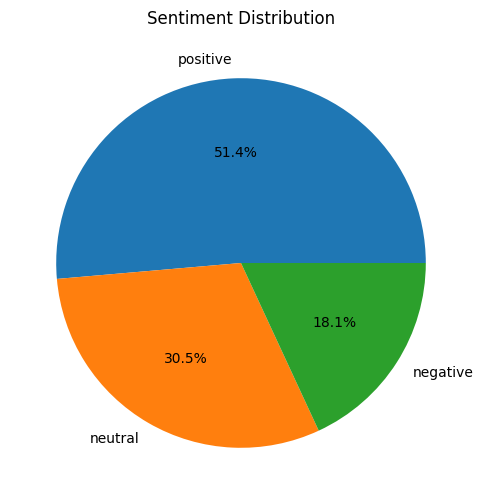

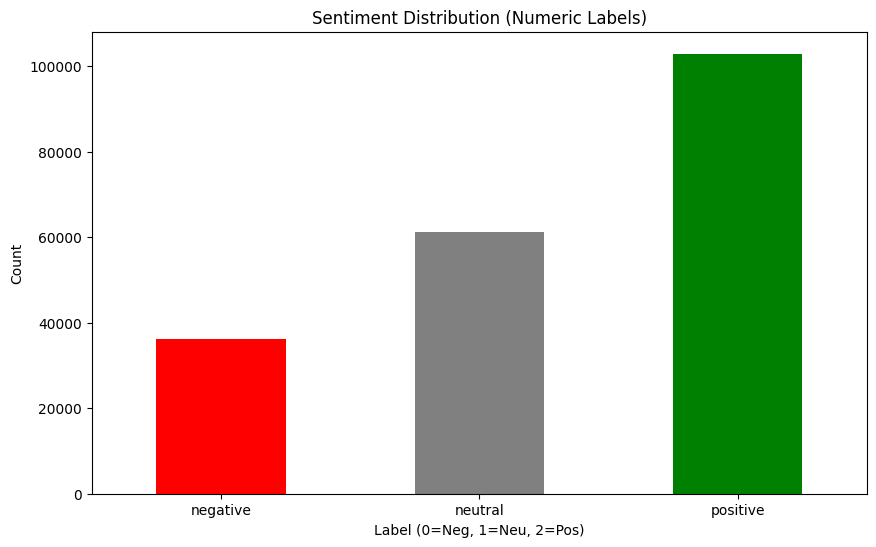


=== 3. Word Frequency Analysis ===
Top 20 Words Overall:
the: 139138
https: 126658
and: 64152
for: 55312
mufc: 41145
lfc: 31726
arsenal: 31078
this: 30928
with: 27828
you: 26292
that: 26068
have: 23680
are: 23029
thfc: 19829
will: 18080
afc: 17943
but: 17782
efc: 16902
from: 16809
not: 16320


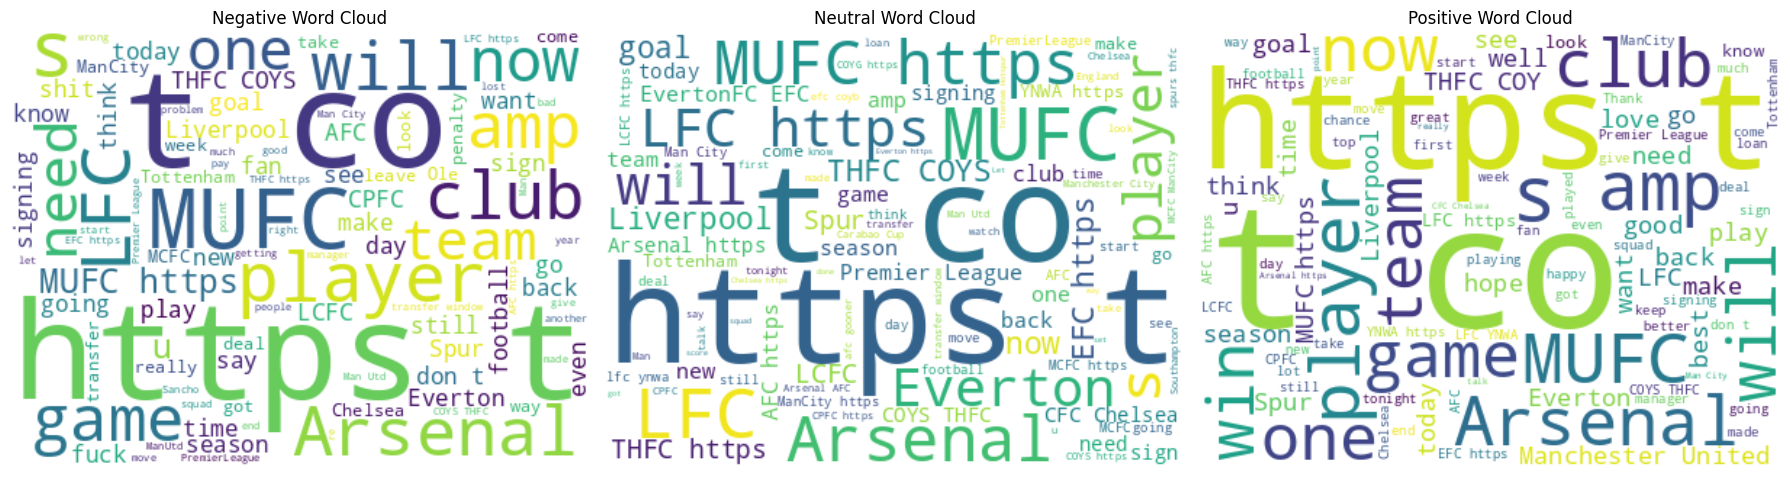


=== 5. Sample Texts by Class ===

NEGATIVE Samples:
- @ChelseaFC I still have no entire clue why us crystal palace wouldn’t go for Abraham. He’s a top sho...
- Pizza fight suggestions wrong, #CPFC wonderkid says in interview with national media #EPL...
- Parish knew COVID was coming and stalled stadium plans as a result 😅 #cpfc https://t.co/f2N0viNnVf...

NEUTRAL Samples:
- Onto Week 2 of Premier League Stars of the Week, where I analyse the highest scoring weekend in Prem...
- Chelsea v Palace kick-off time changed and TV information confirmed https://t.co/ktPCyqCcri #CPFC...
- HE WORKS WHEN HE WANTS, HE WORKS WHEN HE WAAAANTS, @HLTCO HE WORKS WHEN HE WANTS 🦅 #CPFC...

POSITIVE Samples:
- Our palace team will put our hearts out for our fans because we don’t have billions of fans we have ...
- Academy redevelopment update: Exclusive footage shows new site progression https://t.co/wQeyi9tk5H #...
- It’s game week 🙌🏻 we play @RoversLadies Sunday watch all the action after final whistle 

In [ ]:
from collections import Counter

print("=== 1. Basic Dataset Overview ===")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDescriptive Stats (Numeric Columns):")
print(df.describe())

print("\n=== 2. Target Distribution (Sentiment Labels) ===")
label_dist = df['label'].value_counts()
print(label_dist)
print("\nNormalized (%):")
print((label_dist / len(df) * 100).round(2))

# Pie chart for labels
plt.figure(figsize=(8, 6))
label_dist.plot(kind='pie', autopct='%1.1f%%', labels=label_dist.index)
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()

# Bar chart for numeric labels
plt.figure(figsize=(10, 6))
df['label'].value_counts().sort_index().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution (Numeric Labels)')
plt.xlabel('Label (0=Neg, 1=Neu, 2=Pos)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


print("\n=== 3. Word Frequency Analysis ===")
# Top words overall
all_words = ' '.join(df['text'].dropna()).lower()
words = re.findall(r'\b[a-z]{3,}\b', all_words)  # Extract words >2 chars
word_freq = Counter(words)
top_words = word_freq.most_common(20)
print("Top 20 Words Overall:")
for word, count in top_words:
    print(f"{word}: {count}")

# Word clouds by sentiment
sentiment_map = {'negative': 'Negative', 'neutral': 'Neutral', 'positive': 'Positive'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (label, name) in enumerate(sentiment_map.items()):
    subset_text = ' '.join(df[df['label'] == label]['text'].dropna())
    if subset_text:
        wc = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(subset_text)
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'{name} Word Cloud')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center')
        axes[i].set_title(f'{name} Word Cloud')
plt.tight_layout()
plt.show()



print("\n=== 5. Sample Texts by Class ===")
for label in ['negative', 'neutral', 'positive']:
    samples = df[df['label'] == label]['text'].head(3).tolist()
    print(f"\n{label.upper()} Samples:")
    for s in samples:
        print(f"- {s[:100]}...")

print("\nEDA Complete! Check plots above for insights.")

## 4. Preprocessing Pipeline

Apply NLP techniques: lowercasing, noise removal (URLs/mentions/emojis), tokenization (TweetTokenizer), stop-word removal (NLTK), lemmatization (spaCy), and length filtering.

**Output**: `df['cleaned_text']` and 3-class `label` (0=neg, 1=neu, 2=pos) from polarity thresholds (-0.05/0.05).

**Why?**: Reduces noise, normalizes text for better model performance. Drops duplicates/empty rows.

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Enable progress_apply
tqdm.pandas()

# Load spaCy for lemmatization
nlp = spacy.load('en_core_web_sm')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean raw tweet text: remove URLs, mentions, hashtags symbols, RTs, emojis, extra noise.
    """
    if pd.isna(text) or text == '':
        return ''

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove # but keep the word after it (for sentiment context)
    text = re.sub(r'#', '', text)

    # Remove RTs
    text = re.sub(r'RT\s*:?\s*', '', text)

    # Remove emojis (using demojize to convert to text, then strip tags)
    text = emoji.demojize(text)
    text = re.sub(r':[^:]*:', '', text)

    # Keep alphanumeric, basic punctuation, lowercase, strip extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text).lower().strip()
    text = re.sub(r'\s+', ' ', text)

    return text

def lemmatize_tokens(tokens):
    """
    Lemmatize tokens using spaCy, filter stopwords and short words.
    """
    if not tokens:
        return []

    doc = nlp(' '.join(tokens))
    lemmatized = [
        token.lemma_.lower()
        for token in doc
        if token.lemma_.lower() not in stop_words
        and len(token.lemma_) > 2
        and not token.is_stop
    ]
    return lemmatized

def preprocess_text(text):
    """
    Full preprocessing: clean -> tokenize -> lemmatize -> join.
    """
    cleaned = clean_text(text)
    if not cleaned:
        return ''

    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(cleaned)

    lemmatized = lemmatize_tokens(tokens)

    return ' '.join(lemmatized)

def add_labels_from_polarity(df, neg_threshold=-0.05, pos_threshold=0.05):
    """
    Add ternary 'label' column using existing 'polarity' only.
    Assumes polarity scale: e.g., -1 to +1.
    - 'negative': polarity < neg_threshold
    - 'neutral': neg_threshold <= polarity <= pos_threshold
    - 'positive': polarity > pos_threshold
    Adjust thresholds if your polarity scale differs (e.g., for VADER-like: -0.05/0.05).
    """
    def classify_polarity(p):
        if pd.isna(p):
            return 'neutral'
        if p < neg_threshold:
            return 'negative'
        elif p <= pos_threshold:
            return 'neutral'
        else:
            return 'positive'

    df['label'] = df['polarity'].apply(classify_polarity)
    print("Labels added: 'label' (3 classes from polarity: negative/neutral/positive)")
    print(f"Thresholds used: negative < {neg_threshold}, neutral [{neg_threshold}-{pos_threshold}], positive > {pos_threshold}")
    return df

# Full Preprocessing Pipeline
def run_full_preprocessing(preprocessed_folder='preprocessed_data/'):
    """
    Check for preprocessed CSV; if exists, load it. Else, preprocess global 'df', save, and return.
    Assumes 'df' is already loaded from previous cell.
    """
    # Create folder if needed
    os.makedirs(preprocessed_folder, exist_ok=True)

    preprocessed_path = os.path.join(preprocessed_folder, 'preprocessed_epl_tweets.csv')

    if os.path.exists(preprocessed_path):
        print(f"Preprocessed file exists. Loading from '{preprocessed_path}'...")
        df_preprocessed = pd.read_csv(preprocessed_path)
        print(f"Loaded shape: {df_preprocessed.shape}")

        # Quick check on class composition
        if 'label' in df_preprocessed.columns:
            print("\nClass Composition (Label Distribution in %):")
            class_dist = df_preprocessed['label'].value_counts(normalize=True).sort_index() * 100
            class_names = {'negative': 'Negative', 'neutral': 'Neutral', 'positive': 'Positive'}
            for label, pct in class_dist.items():
                print(f"{class_names[label]}: {pct:.2f}%")

            if len(class_dist) > 1:
                imbalance_ratio = class_dist.max() / class_dist.min()
                print(f"Imbalance Ratio (majority/minority class): {imbalance_ratio:.2f}")
        else:
            print("Warning: 'label' column not found in preprocessed data.")

        return df_preprocessed

    else:
        print("No preprocessed file found. Running full preprocessing on global 'df'...")
        global df

        print(f"Raw shape: {df.shape}")

        # Check columns
        print("Columns:", df.columns.tolist())

        # Remove exact duplicates based on 'text'
        print("Removing duplicates...")
        df.drop_duplicates(subset=['text'], inplace=True)
        print(f"Shape after dedup: {df.shape}")

        # Add 3-class labels using polarity only
        df = add_labels_from_polarity(df)

        # Print class composition (distribution in percentages) to check imbalance
        print("\nClass Composition (Label Distribution in %):")
        class_dist = df['label'].value_counts(normalize=True).sort_index() * 100
        class_names = {'negative': 'Negative', 'neutral': 'Neutral', 'positive': 'Positive'}
        for label, pct in class_dist.items():
            print(f"{class_names[label]}: {pct:.2f}%")

        if len(class_dist) > 1:
            imbalance_ratio = class_dist.max() / class_dist.min()
            print(f"Imbalance Ratio (majority/minority class): {imbalance_ratio:.2f}")

        # Preprocess text
        print("Preprocessing texts...")
        df['cleaned_text'] = df['text'].progress_apply(preprocess_text)

        # Drop rows with empty cleaned text
        initial_len = len(df)
        df = df[df['cleaned_text'] != ''].reset_index(drop=True)
        print(f"Shape after dropping empty texts: {df.shape} (dropped {initial_len - len(df)} rows)")

        # Add length features for EDA
        df['text_len'] = df['text'].str.len()
        df['cleaned_len'] = df['cleaned_text'].str.len()

        # Save preprocessed data
        df.to_csv(preprocessed_path, index=False)
        print(f"Preprocessed data saved to '{preprocessed_path}'")

        return df

# Run the pipeline
if __name__ == "__main__":
    df_preprocessed = run_full_preprocessing()

Preprocessed file exists. Loading from 'preprocessed_data/preprocessed_epl_tweets.csv'...
Loaded shape: (200366, 19)

Class Composition (Label Distribution in %):
Negative: 18.09%
Neutral: 30.53%
Positive: 51.38%
Imbalance Ratio (majority/minority class): 2.84


In [ ]:
df_preprocessed['label'].value_counts()

,count
label,
positive,102940
neutral,61180
negative,36246


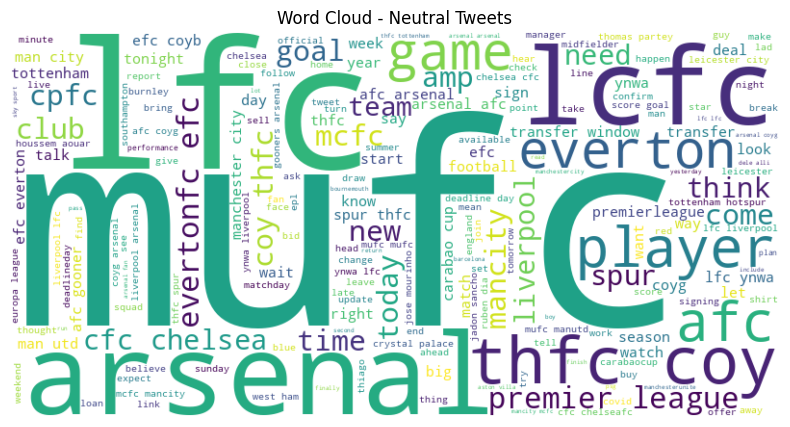

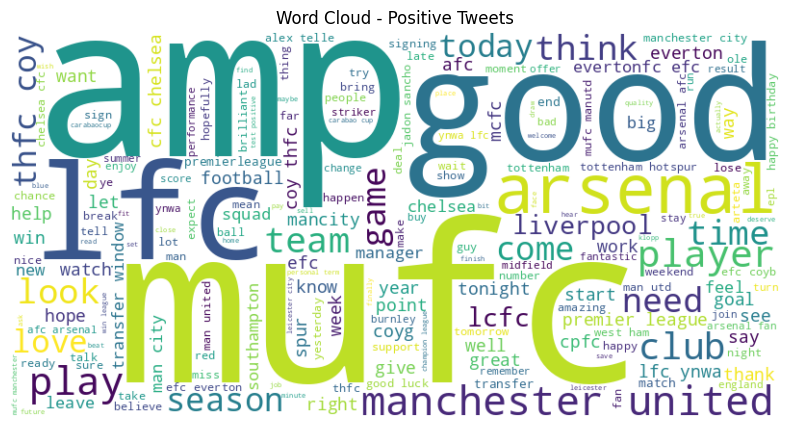

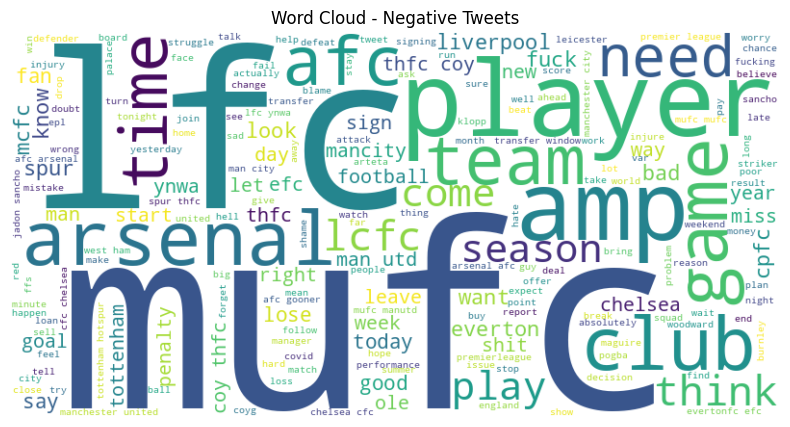

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

unique_labels = df['label'].unique()
sentiment_map = {'negative': 'Negative', 'neutral': 'Neutral', 'positive': 'Positive'}  # For titles

for label in unique_labels:
    if label not in sentiment_map:
        continue

    text_data = ' '.join(df[df['label'] == label]['cleaned_text'].dropna())

    if not text_data.strip():
        print(f"No text data for {label} class.")
        continue

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200
    ).generate(text_data)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {sentiment_map[label]} Tweets')
    plt.show()

In [ ]:
# Train-test split
X = df_preprocessed['cleaned_text']
y = df_preprocessed['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Label distribution in train:", y_train.value_counts(normalize=True).sort_index())
print("Label distribution in test:", y_test.value_counts(normalize=True).sort_index())

Train shape: (160292,), Test shape: (40074,)
Label distribution in train: label
negative    0.180901
neutral     0.305343
positive    0.513756
Name: proportion, dtype: float64
Label distribution in test: label
negative    0.180890
neutral     0.305335
positive    0.513775
Name: proportion, dtype: float64


## 5. TF-IDF + Logistic Regression (Baseline Model)

Extract features with TF-IDF (n-grams, max_features=5000), train multinomial Logistic Regression for 3-class classification.

**Steps**:
- Split: 80/20 train/test.
- Vectorize: `TfidfVectorizer()`.
- Train: `LogisticRegression(multi_class='multinomial')`
- Evaluate: Classification report, confusion matrix, F1-macro.

**Why Baseline?**: Fast, interpretable; benchmarks BERT.

In [ ]:

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:

# Logistic Regression model
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'neutral', 'positive']))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results
              precision    recall  f1-score   support

    negative       0.80      0.63      0.70      7249
     neutral       0.80      0.90      0.84     12236
    positive       0.89      0.89      0.89     20589

    accuracy                           0.84     40074
   macro avg       0.83      0.80      0.81     40074
weighted avg       0.84      0.84      0.84     40074



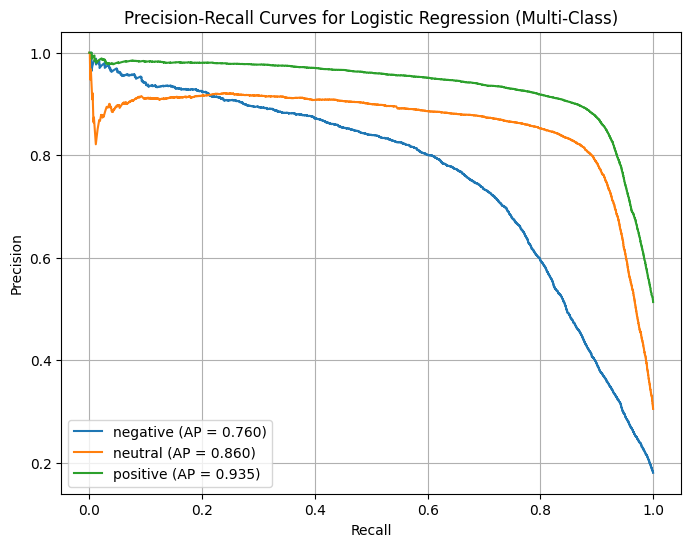

In [ ]:
# Imports for curves (ensure these are run)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize

# Encode string labels to integers (0: negative, 1: neutral, 2: positive)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Assuming y_train is also strings; encode if needed
y_test_encoded = le.transform(y_test)  # y_test is strings

# Get prediction probabilities (model was fit on encoded y_train)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)

# Binarize y_test_encoded for multi-class handling (one-vs-rest)
classes = le.classes_  # ['negative', 'neutral', 'positive']
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Plot Precision-Recall Curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f'{classes[i]} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Logistic Regression (Multi-Class)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

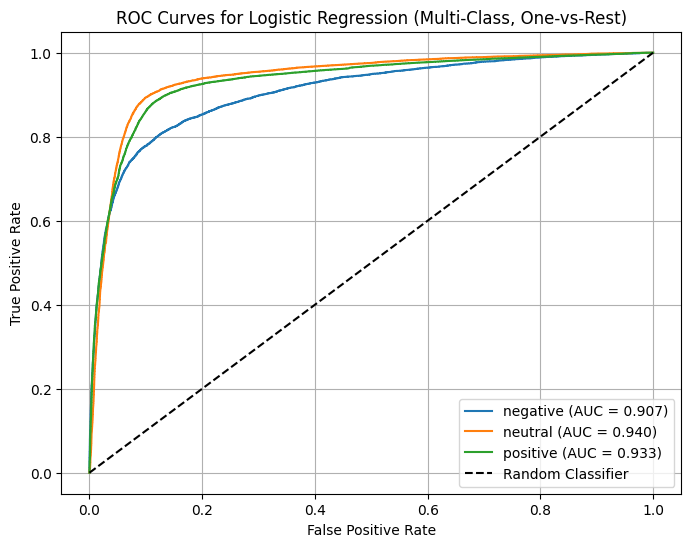

In [ ]:
# Plot ROC Curves (continuing from previous cell)
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression (Multi-Class, One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

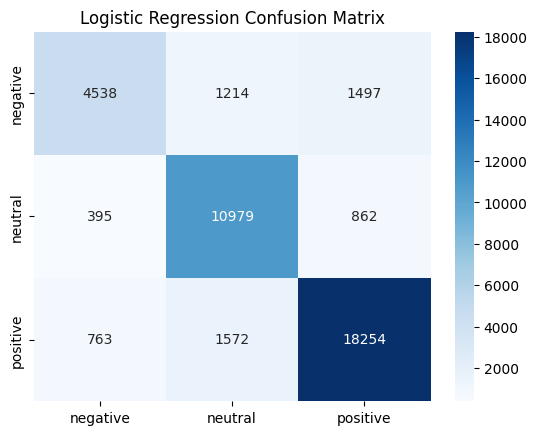

In [ ]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)
plt.title('Logistic Regression Confusion Matrix')
plt.show()


## 6. BERT Fine-Tuning (Advanced Model)

Fine-tune `bert-base-uncased` for sequence classification on tokenized texts.

**Steps**:
- Tokenize: `BertTokenizer` (max_len=128).
- Dataset: Hugging Face `Dataset` with labels.
- Train: `Trainer` API (3 epochs, lr=2e-5, batch=16).
- Evaluate: Accuracy, F1 on test set.

**Note**: Use GPU; ~4-5 hrs on T4. Outputs contextual embeddings for nuanced sentiment.

While Training in full sample, it took about 4 hours to train the model and then the runtime disconnected. Due to this only evalution matrix was able to be computed due to time constraint. So, I have trained the model on the sub sample as well so that the graphs and predictions can be made.

In [ ]:

# BERT: Subsample data
# df_sample = df.sample(n=10000, random_state=42)
df_sample = df
X_bert = df_sample['text'].tolist()
y_bert = df_sample['label'].tolist()

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)


In [ ]:

# HuggingFace datasets
train_dataset = Dataset.from_dict({'text': X_train_bert, 'label': y_train_bert})
test_dataset = Dataset.from_dict({'text': X_test_bert, 'label': y_test_bert})

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


In [ ]:

# BERT Model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels, average='macro')


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_dir="./logs",
)


In [ ]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,F1
1,0.193100,0.171265,0.945963
2,0.106800,0.162607,0.956285
3,0.085100,0.132273,0.962745


TrainOutput(global_step=29124, training_loss=0.15588331265103078, metrics={'train_runtime': 10951.7912, 'train_samples_per_second': 42.547, 'train_steps_per_second': 2.659, 'total_flos': 3.065067403632461e+16, 'train_loss': 0.15588331265103078, 'epoch': 3.0})

In [ ]:

# BERT Evaluation
eval_results = trainer.evaluate(test_dataset)
print(eval_results)

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test_bert,
    y_pred_bert,
    target_names=['negative', 'neutral', 'positive']
))


{'eval_loss': 0.13227303326129913, 'eval_f1': 0.9627449803439266, 'eval_runtime': 288.9656, 'eval_samples_per_second': 134.379, 'eval_steps_per_second': 8.399, 'epoch': 3.0}
              precision    recall  f1-score   support

    negative       0.94      0.95      0.95      7349
     neutral       0.97      0.96      0.96     10754
    positive       0.98      0.98      0.98     20728

    accuracy                           0.97     38831
   macro avg       0.96      0.96      0.96     38831
weighted avg       0.97      0.97      0.97     38831



In [ ]:

tqdm.pandas()

def clean_text(text):
    """
    Basic cleaning for BERT: remove URLs, mentions, RTs, emojis, extra noise; lowercase.
    """
    if pd.isna(text) or text == '':
        return ''

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove # but keep the word after it (for sentiment context)
    text = re.sub(r'#', '', text)

    # Remove RTs
    text = re.sub(r'RT\s*:?\s*', '', text)

    # Remove emojis (using demojize to convert to text, then strip tags)
    text = emoji.demojize(text)
    text = re.sub(r':[^:]*:', '', text)

    # Keep alphanumeric, basic punctuation, lowercase, strip extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text).lower().strip()
    text = re.sub(r'\s+', ' ', text)

    return text

def add_labels_from_polarity(df, neg_threshold=-0.05, pos_threshold=0.05):
    """
    Add ternary 'label' column using existing 'polarity' only.
    Assumes polarity scale: e.g., -1 to +1.
    - 'negative': polarity < neg_threshold
    - 'neutral': neg_threshold <= polarity <= pos_threshold
    - 'positive': polarity > pos_threshold
    Adjust thresholds if your polarity scale differs (e.g., for VADER-like: -0.05/0.05).
    """
    def classify_polarity(p):
        if pd.isna(p):
            return 'neutral'  # Or drop NaNs: raise ValueError if strict
        if p < neg_threshold:
            return 'negative'
        elif p <= pos_threshold:
            return 'neutral'
        else:
            return 'positive'

    df['label'] = df['polarity'].apply(classify_polarity)
    print("Labels added: 'label' (3 classes from polarity: negative/neutral/positive)")
    print(f"Thresholds used: negative < {neg_threshold}, neutral [{neg_threshold}-{pos_threshold}], positive > {pos_threshold}")
    return df

# Full Pipeline: Load, derive labels, basic clean, store in df
def run_preprocessing_pipeline(folder_path='data/'):
    """
    Load data, derive labels from polarity, apply basic cleaning, save results.
    Returns processed df.
    """
    # Load dataset
    def load_dataset(folder_path='data/'):
        all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
        df_list = []
        for file in all_files:
            try:
                df_temp = pd.read_csv(
                    os.path.join(folder_path, file),
                    engine='python',
                    on_bad_lines='skip'
                )
                df_list.append(df_temp)
            except Exception as e:
                print(f"Error reading {file}: {e}")
        df = pd.concat(df_list, ignore_index=True)
        return df

    df = load_dataset(folder_path)
    print(f"Raw shape: {df.shape}")

    # Check columns
    print("Columns:", df.columns.tolist())

    # Remove exact duplicates based on 'text'
    print("Removing duplicates...")
    df.drop_duplicates(subset=['text'], inplace=True)
    print(f"Shape after dedup: {df.shape}")

    # Add labels using polarity only
    df = add_labels_from_polarity(df)

    # Basic text cleaning
    print("Applying basic text cleaning...")
    df['cleaned_text'] = df['text'].progress_apply(clean_text)

    # Drop rows with empty cleaned text
    initial_len = len(df)
    df = df[df['cleaned_text'] != ''].reset_index(drop=True)
    print(f"Shape after dropping empty texts: {df.shape} (dropped {initial_len - len(df)} rows)")

    # Add length features
    df['text_len'] = df['text'].str.len()
    df['cleaned_len'] = df['cleaned_text'].str.len()

    return df

# Run the pipeline
if __name__ == "__main__":
    df = run_preprocessing_pipeline('data/')

Raw shape: (211342, 15)
Columns: ['created_at', 'file_name', 'followers', 'friends', 'group_name', 'location', 'retweet_count', 'screenname', 'search_query', 'text', 'twitter_id', 'username', 'polarity', 'partition_0', 'partition_1']
Removing duplicates...
Shape after dedup: (200375, 15)
Labels added: 'label' (3 classes from polarity: negative/neutral/positive)
Thresholds used: negative < -0.05, neutral [-0.05-0.05], positive > 0.05
Applying basic text cleaning...


100%|██████████| 200375/200375 [00:25<00:00, 7740.98it/s]


Shape after dropping empty texts: (200374, 17) (dropped 1 rows)


In [ ]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

# BERT: Subsample data
df_sample = df.sample(n=10000, random_state=42)
X_bert = df_sample['text'].tolist()
y_bert_str = df_sample['label'].tolist()  # Strings

# Map to numeric
y_bert = [label_map[label] for label in y_bert_str]

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)


In [ ]:
# HuggingFace datasets
train_dataset = Dataset.from_dict({'text': X_train_bert, 'label': y_train_bert})
test_dataset = Dataset.from_dict({'text': X_test_bert, 'label': y_test_bert})

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:

# BERT Model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels, average='macro')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_dir="./logs",
)


In [ ]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,F1
1,0.553300,0.373185,0.851604
2,0.267300,0.324003,0.875099
3,0.147000,0.416264,0.883949


TrainOutput(global_step=1500, training_loss=0.32253951009114584, metrics={'train_runtime': 638.2792, 'train_samples_per_second': 37.601, 'train_steps_per_second': 2.35, 'total_flos': 1578680506368000.0, 'train_loss': 0.32253951009114584, 'epoch': 3.0})

In [ ]:

# BERT Evaluation
eval_results = trainer.evaluate(test_dataset)
print(eval_results)

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test_bert,
    y_pred_bert,
    target_names=['negative', 'neutral', 'positive']
))


{'eval_loss': 0.416263610124588, 'eval_f1': 0.8839489300231822, 'eval_runtime': 12.7584, 'eval_samples_per_second': 156.76, 'eval_steps_per_second': 9.798, 'epoch': 3.0}
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82       365
     neutral       0.94      0.87      0.90       608
    positive       0.91      0.95      0.93      1027

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000



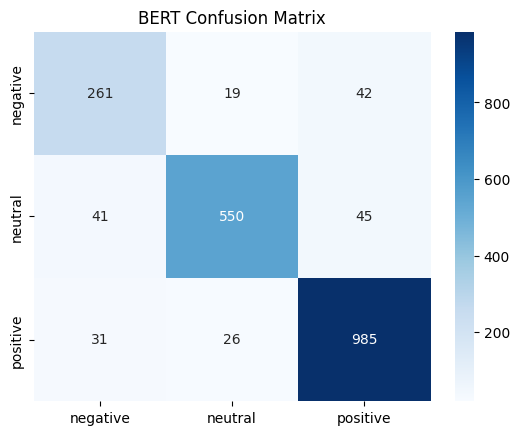

In [ ]:

cm_bert = confusion_matrix(y_test_bert, y_pred_bert)
sns.heatmap(
    cm_bert, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)
plt.title('BERT Confusion Matrix')
plt.show()


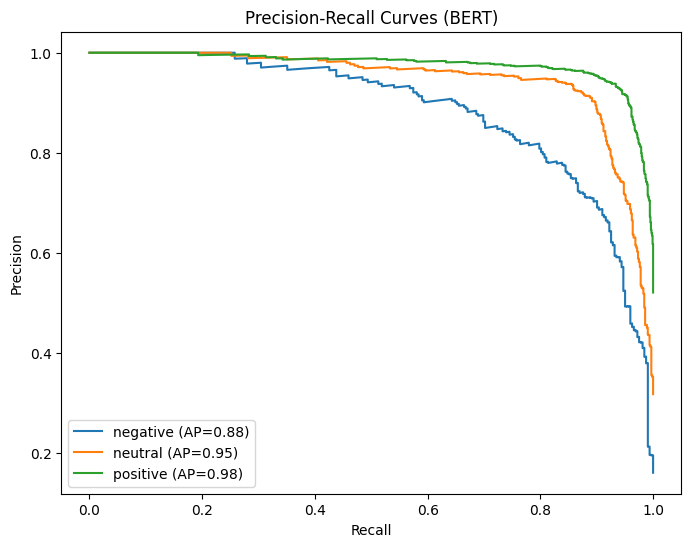

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Probabilities from BERT
y_score_bert = torch.nn.functional.softmax(
    torch.tensor(predictions.predictions), dim=1
).numpy()

y_test_bert_bin = label_binarize(y_test_bert, classes=[0, 1, 2])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(
        y_test_bert_bin[:, i], y_score_bert[:, i]
    )
    ap = average_precision_score(
        y_test_bert_bin[:, i], y_score_bert[:, i]
    )
    plt.plot(recall, precision, label=f'{class_name} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (BERT)')
plt.legend()
plt.show()


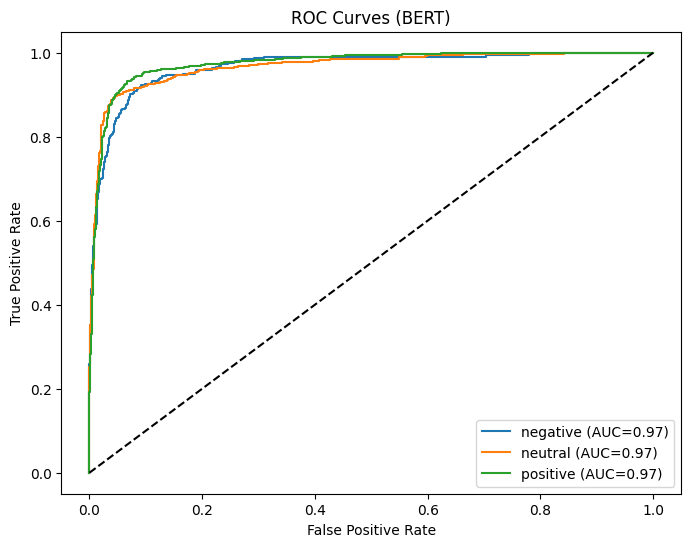

In [ ]:
plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bert_bin[:, i], y_score_bert[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (BERT)')
plt.legend()
plt.show()


In [ ]:

# NLTK and spaCy setup (from your preprocessing code)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
tqdm.pandas()
nlp = spacy.load('en_core_web_sm')
stop_words = set(stopwords.words('english'))

# Preprocessing functions (copied from your code)
def clean_text(text):
    """
    Clean raw tweet text: remove URLs, mentions, hashtags symbols, RTs, emojis, extra noise.
    """
    if pd.isna(text) or text == '':
        return ''

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove # but keep the word after it (for sentiment context)
    text = re.sub(r'#', '', text)

    # Remove RTs
    text = re.sub(r'RT\s*:?\s*', '', text)

    # Remove emojis (using demojize to convert to text, then strip tags)
    text = emoji.demojize(text)
    text = re.sub(r':[^:]*:', '', text)

    # Keep alphanumeric, basic punctuation, lowercase, strip extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text).lower().strip()
    text = re.sub(r'\s+', ' ', text)

    return text

def lemmatize_tokens(tokens):
    """
    Lemmatize tokens using spaCy, filter stopwords and short words.
    """
    if not tokens:
        return []

    doc = nlp(' '.join(tokens))
    lemmatized = [
        token.lemma_.lower()
        for token in doc
        if token.lemma_.lower() not in stop_words
        and len(token.lemma_) > 2
        and not token.is_stop
    ]
    return lemmatized

def preprocess_text(text):
    """
    Full preprocessing: clean -> tokenize -> lemmatize -> join.
    """
    cleaned = clean_text(text)
    if not cleaned:
        return ''

    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(cleaned)

    lemmatized = lemmatize_tokens(tokens)

    return ' '.join(lemmatized)


# Sample tweets (one per class, EPL-themed; true labels as strings)
sample_tweets = [
    ("Arsenal's defense is a joke, worst team ever! What a disaster. #COYG", "negative"),
    ("Man City vs Liverpool match starts at 8 PM GMT tomorrow.", "neutral"),
    ("What an incredible goal from Salah! Liverpool are unstoppable! #LFC", "positive")
]

true_labels = [label for _, label in sample_tweets]
raw_tweets = [tweet for tweet, _ in sample_tweets]

# Preprocess samples
processed_samples = [preprocess_text(tweet) for tweet in raw_tweets]

# Label map for numeric to string (for BERT, which outputs ints)
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Prediction function for LR (handles string or numeric predictions robustly)
def predict_lr(texts, vectorizer, model):
    processed = [preprocess_text(t) for t in texts] if isinstance(texts, list) else preprocess_text(texts)
    X = vectorizer.transform(processed)
    preds = model.predict(X)
    # Handle if model predicts strings or ints
    if isinstance(preds[0], str):
        return list(preds)
    else:
        return [label_map.get(int(p), str(p)) for p in preds]

# Prediction function for BERT
def predict_bert(texts, tokenizer, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
    if isinstance(texts, str):
        texts = [texts]
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        preds_num = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
    return [label_map.get(int(p), str(p)) for p in preds_num]

# Run predictions
lr_preds = predict_lr(raw_tweets, vectorizer, lr_model)
bert_preds = predict_bert(processed_samples, tokenizer, model)

# Display results
results = pd.DataFrame({
    'Raw Tweet': raw_tweets,
    'Processed Text': processed_samples,
    'True Label': true_labels,
    'LR Prediction': lr_preds,
    'BERT Prediction': bert_preds
})
print("Prediction Results on Sample Tweets:")
print(results)

# Simple accuracy check
lr_acc = np.mean(np.array(lr_preds) == np.array(true_labels))
bert_acc = np.mean(np.array(bert_preds) == np.array(true_labels))
print(f"\nSample Accuracy - LR: {lr_acc:.2f} ({sum(np.array(lr_preds) == np.array(true_labels))}/3 correct)")
print(f"BERT: {bert_acc:.2f} ({sum(np.array(bert_preds) == np.array(true_labels))}/3 correct)")

print("\n=== Confidence Scores ===")
if hasattr(lr_model, 'predict_proba'):
    lr_probas = lr_model.predict_proba(vectorizer.transform(processed_samples))
    print("LR Probabilities (neg, neu, pos):")
    for i, row in enumerate(lr_probas):
        print(f"Tweet {i+1}: {row.round(2)}")

# For BERT, compute probs directly
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
inputs = tokenizer(processed_samples, return_tensors='pt', padding=True, truncation=True, max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    bert_outputs = model(**inputs)
bert_probas = torch.softmax(bert_outputs.logits, dim=-1).cpu().numpy()
print("\nBERT Probabilities (neg, neu, pos):")
for i, row in enumerate(bert_probas):
    print(f"Tweet {i+1}: {row.round(2)}")

Prediction Results on Sample Tweets:
                                           Raw Tweet  \
0  Arsenal's defense is a joke, worst team ever! ...   
1  Man City vs Liverpool match starts at 8 PM GMT...   
2  What an incredible goal from Salah! Liverpool ...   

                                    Processed Text True Label LR Prediction  \
0      arsenal defense joke bad team disaster coyg   negative      negative   
1      man city liverpool match start gmt tomorrow    neutral       neutral   
2  incredible goal salah liverpool unstoppable lfc   positive       neutral   

  BERT Prediction  
0        negative  
1         neutral  
2        negative  

Sample Accuracy - LR: 0.67 (2/3 correct)
BERT: 0.67 (2/3 correct)

=== Confidence Scores ===
LR Probabilities (neg, neu, pos):
Tweet 1: [0.96 0.   0.04]
Tweet 2: [0.09 0.72 0.18]
Tweet 3: [0.1  0.79 0.11]

BERT Probabilities (neg, neu, pos):
Tweet 1: [0.99 0.   0.  ]
Tweet 2: [0. 1. 0.]
Tweet 3: [0.99 0.   0.  ]


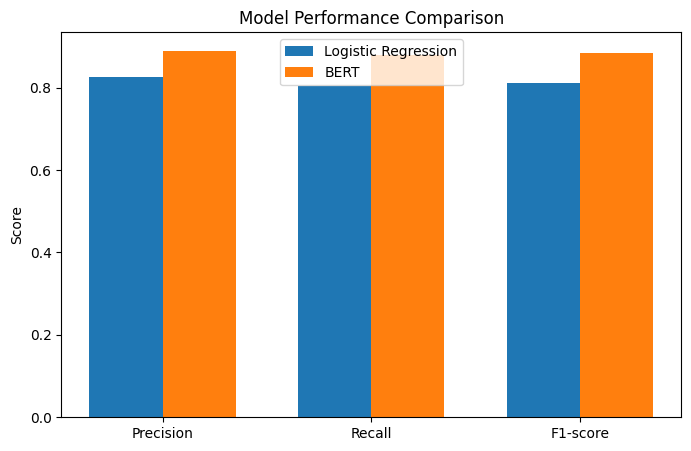

In [ ]:
metrics = ['Precision', 'Recall', 'F1-score']

lr_report = classification_report(
    y_test, y_pred_lr, output_dict=True
)
bert_report = classification_report(
    y_test_bert, y_pred_bert, output_dict=True
)

lr_scores = [
    lr_report['macro avg']['precision'],
    lr_report['macro avg']['recall'],
    lr_report['macro avg']['f1-score']
]

bert_scores = [
    bert_report['macro avg']['precision'],
    bert_report['macro avg']['recall'],
    bert_report['macro avg']['f1-score']
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, bert_scores, width, label='BERT')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()
